# **Asignatura**: Aprendizaje Automático

**Práctica 1**: Aprendizaje supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 28 de Marzo de 2025 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: <mark>CRUZ LORENZO, JOAQUÍN</mark>






**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa** (por ejemplo, en `.pdf`).

- El código debe estar bien comentado (explicando lo que realizan los distintos apartados y/o bloques), y todas las decisiones tomadas y el trabajo desarrollado (incluyendo los conceptos fundamentales subyacentes) deben documentarse ampliamente en celdas de texto. Es obligatorio documentar las valoraciones y decisiones adoptadas en el desarrollo de cada uno de los apartados. Debe incluirse también tanto una descripción de las principales funciones (Python/scikit-learn) empleadas (para mostrar que el alumno comprende, a nivel técnico, lo que está haciendo), como una valoración razonada sobre la calidad de los resultados obtenidos. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- La entrega en PRADO está configurada para permitir sucesivas entregas de la práctica. Desde este punto de vista, se recomienda subir versiones de la práctica a medida que se van realizando los distintos ejercicios propuestos, y no dejarlo todo para el final.  

- Se debe respetar la estructura y secciones del Notebook. Esto servirá para agilizar las correcciones, así como para identificar con facilidad qué ejercicio/apartado se está respondiendo.

- El código **NO debe escribir nada a disco**.

- El **path de lectura desde Google Drive debe ser siempre el mismo**, que es el que se indica en este Notebook.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores. Es decir, un ejercicio con errores de ejecución tendrá una calificación de 0.

- No es válido usar opciones en las entradas (es decir, utilizar el comando `input()`, por ejemplo, para que el usuario escoja el valor de las variables para ejecutar el programa). Para ello, se deben fijar al comienzo los valores
por defecto que se consideren óptimos o que se soliciten en el enunciado.

- Se entrega solamente este Notebook, y no los datos empleados.


# **Ejercicio 1: Problema de clasificación (5 puntos)**

En este ejercicio los alumnos se enfrentarán a un problema de clasificación, que tendrán que abordar de comienzo a fin (desde el análisis exploratorio hasta el entrenamiento y validación de los modelos de aprendizaje automático seleccionados). En particular, se enfrentarán a un problema real de uso de técnicas de aprendizaje automático para desarrollar sistemas olfativos de Inteligencia Artificial mediante **narices electrónicas (*e-Nose*)**, capaces de determinar la calidad de una muestra de carne en base a los gases emitidos por la misma. El conjunto de datos se obteniene a partir de la investigación realizada en el siguiente artículo:

- Feyzioglu, A.; Taspinar, Y.S. Beef Quality Classification with Reduced E-Nose Data Features According to Beef Cut Types. Sensors 2023, 23, 2222 (URL: <a href="https://www.mdpi.com/1424-8220/23/4/2222">https://www.mdpi.com/1424-8220/23/4/2222</a>)



## Contexto y motivación del problema

Los controles de calidad alimentarios son un conjunto de procedimientos y normativas que se implementan para asegurar que los alimentos sean seguros, saludables y cumplan con los estándares establecidos. Esto incluye la supervisión de la producción, el procesamiento, el almacenamiento y la distribución de los alimentos.

Los controles de calidad pueden abarcar desde la inspección de las materias primas hasta la evaluación del producto final, asegurando que no haya contaminantes y que se mantengan las propiedades nutricionales. Normalmente, el proceso de control de calidad conlleva la toma de muestras de alimentos, su transporte a un laboratorio, la realización de diferentes análisis químicos sobre el alimento y la generación de informes positivos o negativos.

Como alternativa a este proceso, **en esta práctica pretendemos elaborar un modelo de aprendizaje automático** capaz de ser integrado en **sistemas olfativos electrónicos (*e-Noses*)** sensibles a los gases que pueden generar diferentes alimentos frescos o en descomposición. En particular, **nos crentraremos en la clasificación de la calidad de cortes de carne** haciendo uso de diferentes gases generados durante el proceso de descomposición de la misma.

Una **e-Nose** (*nariz electrónica*) es un dispositivo diseñado para detectar y analizar olores de manera similar a como lo hace el sentido del olfato en los seres humanos. Utilizan sensores químicos que pueden identificar diferentes compuestos volátiles en el aire (gases).

Estos dispositivos son muy útiles en diversas aplicaciones, como en la industria alimentaria para controlar la calidad de los productos, en la detección de contaminantes en el medio ambiente, o incluso en la medicina para identificar enfermedades a través del análisis de olores específicos.

La tecnología detrás de las narices electrónicas puede variar. En general, combinan sensores, algoritmos de procesamiento de datos y aprendizaje automático para interpretar los olores y proporcionar información útil.

<center>
<img src="https://cdn.open-pr.com/V/5/V505414311_g.jpg" />
</center>

## El conjunto de datos

El conjunto de datos original se encuentra disponible con acceso público en el enlace <a href="https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/XNFVTS">https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/XNFVTS</a>.


Se trata de un conjunto de datos que contiene 12 tipos de cortes de carne diferentes (redondo, solomillo superior, filete de lomo, carne de aleta, lomo corto, falda, terrón, carne de falta, interior/exterior, costillas, espinilla y grasa). Los cortes fueron monitorizados durante 37h hasta su deterioro utilizando 11 tipos de sensores de gas distintos. En cada medición, se asignó una categoría del estado de la carne con 4 etiquetas indicando la calidad "excelente", "buena", "aceptable" y "estropeada".


El **objetivo de la práctica** es desarrollar un modelo de aprendizaje automático capaz de clasificar el estado de una muestra de carne, independientemente de su tipo de corte, partiendo de los datos proporcionados por cada uno de los sensores. El modelo de decisión para determinar el estado de la carne a partir de los datos de los sensores necesita ser entrenado previamente para tener un desempeño correcto. El conjunto de datos a utilizar ha sido preprocesado y extraído a partir de los datos originales, y tiene el siguiente formato:

- **Datos de entrada (X)**: Valor de medición de cada tipo de sensor de gas (en total 11 tipos distintos).
- **Datos de salida (Y)**: Clasificación del tipo de carne.


El conjunto de datos a usar en la práctica se encuentra accesible desde el enlace mostrado en la siguiente celda de código, el cual deberá ser usado por el estudiante para elaborar la práctica.

In [ ]:
import pandas as pd

path_to_data_classification= 'https://www.dropbox.com/scl/fi/3zmizfgjfz5xbbr7xcn2x/MeatClassification.csv?rlkey=81gz5xipne04whrniwqc40r21&st=7o73a6qs&dl=1'

df= pd.read_csv(path_to_data_classification)
df.head(5)


,MQ135,MQ136,MQ137,MQ138,MQ2,MQ3,MQ4,MQ5,MQ6,MQ8,MQ9,Cut,Label
0,16.28,8.01,11.67,13.49,7.09,18.20,7.68,10.39,14.63,34.71,10.53,Striploin,Excellent
1,11.89,8.01,18.43,12.59,7.09,15.08,4.84,19.02,15.35,41.58,11.21,Shin,Spoiled
2,12.87,6.77,22.40,12.05,6.86,16.04,4.60,20.33,18.25,34.51,11.30,Inside-Outside,Spoiled
3,9.78,4.41,12.88,11.35,7.11,13.14,4.76,14.63,19.61,25.20,14.23,Brisket,Acceptable
4,16.42,10.14,13.30,18.36,8.92,27.75,7.62,12.06,16.72,44.07,14.70,Fat,Excellent


El alumnado debe realizar, al menos, las siguientes tareas (que deben ser descritas y abordadas, explícitamente, en la documentación entregada; de hecho, se debe incluir un subapartado en el Notebook para cada una de ellas):

1. Análisis descriptivo del problema y análisis exploratorio de los datos a nuestra disposición.
2. Preprocesado de datos (selección/extracción de características, reducción de dimensionalidad, procesado de datos extremos/atípicos, imputación de datos faltantes, escalado de variables, codificación/transformación de datos, desbalanceo de datos).
3. Definición del protocolo de validación experimental (entrenamiento, validación y test), junto con las métricas de evaluación del rendimiento que corresponda.
4. Selección de, al menos, 3 modelos de aprendizaje automático a emplear en la resolución del problema, de los cuales 1 por lo menos debe ser un $ensemble$.
5. Selección y estimación de valores para hiperparámetros (incluyendo el tipo de regularización a usar).
6. Entrenamiento y estimación del error fuera de la muestra. Discusión de resultados y extracción de conclusiones.

## TAREAS A REALIZAR

### TAREA 1: ANÁLISIS DESCRIPTIVO Y EXPLORATORIO DEL PROBLEMA

#### Análisis descriptivo del problema

El objetivo principal del problema es desarrollar un sistema de aprendizaje automático capaz de clasificar el estado de conservación de muestras de carne a partir de las señales captadas por sensores químicos instalados en un dispositivo denominado nariz electrónica (**e-Nose**).
Una **e-Nose** es un sistema inteligente equipado con sensores capaces de detectar compuestos volátiles en el aire, los cuales pueden relacionarse con el deterioro o la calidad de los alimentos. El conjunto de sensores reacciona químicamente ante la presencia de ciertos gases, generando señales que pueden ser tratadas como datos de entrada para un modelo predictivo.

Contexto del problema

El problema se enmarca dentro del control de calidad alimentaria. Tradicionalmente, este control se realiza mediante análisis físicos y químicos en laboratorio, lo cual implica costos y tiempos elevados. Con una e-Nose y un modelo de clasificación entrenado, se pretende automatizar y acelerar el proceso de evaluación de la calidad de la carne.

En particular, las muestras han sido etiquetadas en cuatro clases según su estado: **Excelente**, **Aceptable**, **Estropeada**

Objetivo del modelo

El modelo deberá, a partir de los valores que registran los sensores (11 variables), predecir en qué categoría se encuentra una muestra de carne en cuanto a su calidad.

Esto supone un problema de **clasificación multiclase**, donde cada muestra estará asociada a una única clase de calidad entre las cuatro posibles.

#### Análisis exploratorio del problema

A continuación tenemos el análisis exploratorio de datos pero primero quiero hacer unas aclaraciones.

¿Qué es el análisis exploratorio de datos (EDA)? ¿Para qué sirve?

El análisis exploratorio de datos es una parte importante en cualquier proyecto de aprendizaje automático. Su objetivo es **comprender la estructura, calidad y distribución de los datos**, así como detectar problemas antes de entrenar los modelos.

Durante esta fase, voy a analizar la información mediante:
  - Resumentes estádisticos.
  - Visualizaciones gráficas.
  - Detección de valores nulos o atípicos.
  - Estudio de la distribución de clases.
  - Análisis de correlaciones entre variables.

Realizar una buena EDA permite tomar decisiones informadas sobre el preprocesamiento, la selección de modelos y las métricas de evaluación. En esta práctica, el EDA se centra en estudiar las señales captadas por la e-Nose para evaluar su potencial predictivo sobre la calidad de la carne.

Dimensiones del dataset: (2400, 13)


,MQ135,MQ136,MQ137,MQ138,MQ2,MQ3,MQ4,MQ5,MQ6,MQ8,MQ9,Cut,Label
0,16.28,8.01,11.67,13.49,7.09,18.20,7.68,10.39,14.63,34.71,10.53,Striploin,Excellent
1,11.89,8.01,18.43,12.59,7.09,15.08,4.84,19.02,15.35,41.58,11.21,Shin,Spoiled
2,12.87,6.77,22.40,12.05,6.86,16.04,4.60,20.33,18.25,34.51,11.30,Inside-Outside,Spoiled
3,9.78,4.41,12.88,11.35,7.11,13.14,4.76,14.63,19.61,25.20,14.23,Brisket,Acceptable
4,16.42,10.14,13.30,18.36,8.92,27.75,7.62,12.06,16.72,44.07,14.70,Fat,Excellent



 Valores nulos: por columna:
MQ135    0
MQ136    0
MQ137    0
MQ138    0
MQ2      0
MQ3      0
MQ4      0
MQ5      0
MQ6      0
MQ8      0
MQ9      0
Cut      0
Label    0
dtype: int64

 Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MQ135   2400 non-null   float64
 1   MQ136   2400 non-null   float64
 2   MQ137   2400 non-null   float64
 3   MQ138   2400 non-null   float64
 4   MQ2     2400 non-null   float64
 5   MQ3     2400 non-null   float64
 6   MQ4     2400 non-null   float64
 7   MQ5     2400 non-null   float64
 8   MQ6     2400 non-null   float64
 9   MQ8     2400 non-null   float64
 10  MQ9     2400 non-null   float64
 11  Cut     2400 non-null   object 
 12  Label   2400 non-null   object 
dtypes: float64(11), object(2)
memory usage: 243.9+ KB
None

 Resument estadístico de las variables numéricas:


,MQ135,MQ136,MQ137,MQ138,MQ2,MQ3,MQ4,MQ5,MQ6,MQ8,MQ9
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,12.867592,8.653604,16.154671,12.335779,6.928496,14.679063,6.528142,15.001271,16.379921,35.730154,12.122863
std,2.828903,6.989394,5.454674,2.669185,1.560192,3.434043,3.498708,5.015889,6.164918,6.735156,2.168585
min,8.030000,2.780000,3.160000,7.700000,3.870000,7.880000,2.230000,5.600000,2.910000,15.990000,8.230000
25%,10.570000,5.250000,13.040000,10.310000,5.720000,12.680000,4.660000,11.460000,15.202500,31.570000,10.410000
50%,12.920000,6.800000,17.000000,12.050000,6.750000,14.470000,5.410000,14.390000,16.340000,36.780000,11.800000
75%,14.400000,8.070000,19.930000,13.820000,7.490000,15.987500,7.530000,17.820000,18.170000,41.320000,13.610000
max,20.510000,39.030000,28.670000,19.910000,12.640000,29.670000,24.250000,32.610000,41.050000,49.170000,18.170000



 Distribución de la variable 'class':
Label
Excellent     600
Spoiled       600
Acceptable    600
Good          600
Name: count, dtype: int64


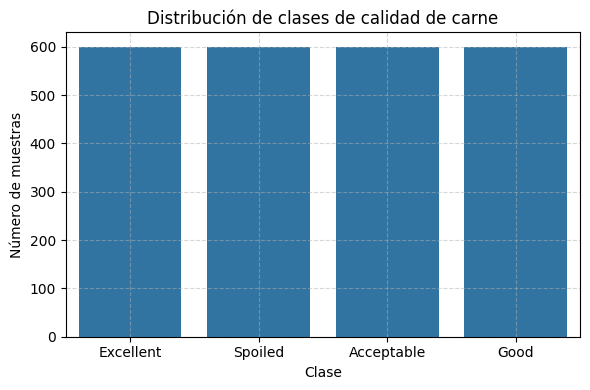

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el conjunto de datos
url = 'https://www.dropbox.com/scl/fi/3zmizfgjfz5xbbr7xcn2x/MeatClassification.csv?rlkey=81gz5xipne04whrniwqc40r21&st=7o73a6qs&dl=1'
df = pd.read_csv(url)

# Vista general
print("Dimensiones del dataset:", df.shape)
display(df.head())

# Valores nulos
print("\n Valores nulos: por columna:")
print(df.isnull().sum())

# Información general
print("\n Información del dataset:")
print(df.info())

# Resumen estadístico
print("\n Resument estadístico de las variables numéricas:")
display(df.describe())

# Distribución de clases (variable objeto)
print("\n Distribución de la variable 'class':")
print(df['Label'].value_counts())

# Gráfica de barras de la distribución de clases
plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=df)
plt.title('Distribución de clases de calidad de carne')
plt.xlabel('Clase')
plt.ylabel('Número de muestras')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Análisis de correlación entre sensores

Para identificar relaciones lineales entre las variables numéricas (los sensores),he calculado la **matriz de correlación**. Esta herramienta permite detectar redundancias o posibles dependencias entre sensores, lo cual es útil si más adelante se desea aplicar reducción de dimensionalidad o seleccionar atributos más informativos.

El mapa de calor generado representa los coeficientes de correlación de Pearson entre los distintos sensores. Un valor cercano a 1 indica una correlación positiva fuerte, mientras que un valor cercano a -1 indica una correlación negtiva fuerte. Valores cercanos a 0 indican una baja correlación.

En este caso, no se observan correlaciones excesivamente altas que indiquen variables duplicadas o completamente dependientes, por lo que es necesario eliminar sensores en esta fase.

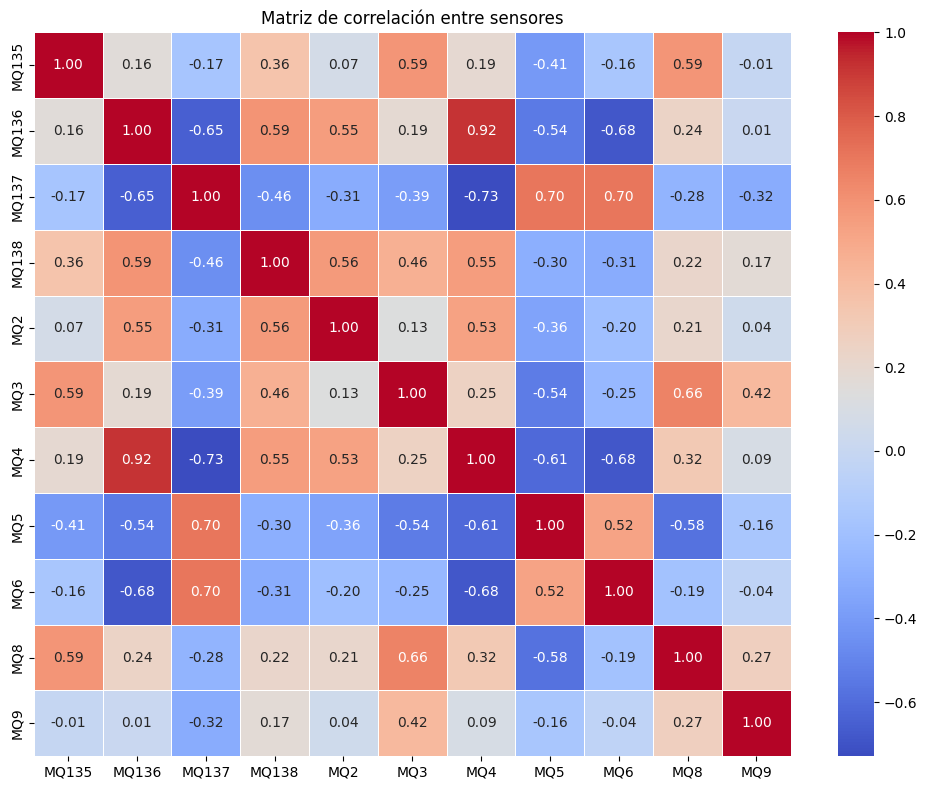

In [ ]:
# Filtramos solo las columnas numéricas (los sensores)
sensor = df.select_dtypes(include='number')

# Calculamos la matriz de correlación
matriz_corr = sensor.corr()

# Visualizamos el mapa de calor de correlación
plt.figure(figsize=(10,8))
sns.heatmap(matriz_corr, annot = True, fmt = ".2f", cmap = 'coolwarm', linewidths = 0.5)
plt.title("Matriz de correlación entre sensores")
plt.tight_layout()
plt.show()

### TAREA 2: PREPROCESADO DE DATOS

El preprocesado de datos es una fase esencial antes del entrenamiento de modelos. En este caso, se han realizado los siguientes pasos:

1. **Codificación de la variable objeto** ('Label') mediante 'LabelEncoder', ya que los algoritmos de clasificación de 'scikit-learn' requieren que las clases sean numéricas.

2. **Escalado de las variables de entrada** con 'StandardScaler', para que todos los sensores que tengna de media cero y desviación típica uno. Esto es especialmente importante para algoritmos sensibles a la escala como la regresión logística y SVC.

3. **División del conjunto de datos** en entrenamiento (80%) y test (20%), utilizando 'stratify = y' para mantener la proporción de clases en ambos subconjuntos.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import pandas as pd

# Volvemos a cargar el conjunto de datos
url = 'https://www.dropbox.com/scl/fi/3zmizfgjfz5xbbr7xcn2x/MeatClassification.csv?rlkey=81gz5xipne04whrniwqc40r21&st=7o73a6qs&dl=1'
df = pd.read_csv(url)

# Copia del dataset
datos = df.copy()

# Codificación de la variable objeto
label_encoder = LabelEncoder()
datos['Label_encoded'] = label_encoder.fit_transform(datos['Label'])

# Separar variables predictores y clase
X = datos.drop(columns=['Label', 'Label_encoded', 'Cut']) # Sensores
y = datos['Label_encoded']

# Escalado de sensores
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en entrenamiento y test (estratificado para mantener proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, stratify = y, random_state = 42)

# Clases codificadas
print("Clases codificadas:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Clases codificadas: {'Acceptable': np.int64(0), 'Excellent': np.int64(1), 'Good': np.int64(2), 'Spoiled': np.int64(3)}


#### Datos faltantes

In [ ]:
print("¿Hay valores nulos en el conjunto de datos?")
print(df.isnull().sum())

¿Hay valores nulos en el conjunto de datos?
MQ135    0
MQ136    0
MQ137    0
MQ138    0
MQ2      0
MQ3      0
MQ4      0
MQ5      0
MQ6      0
MQ8      0
MQ9      0
Cut      0
Label    0
dtype: int64


No se han encontrado valores nulos en el conjunto de datos, por lo que no ha sido necesario aplicar técnicas de imputación.

#### Procesado de datos externos / atípicos (outliers)

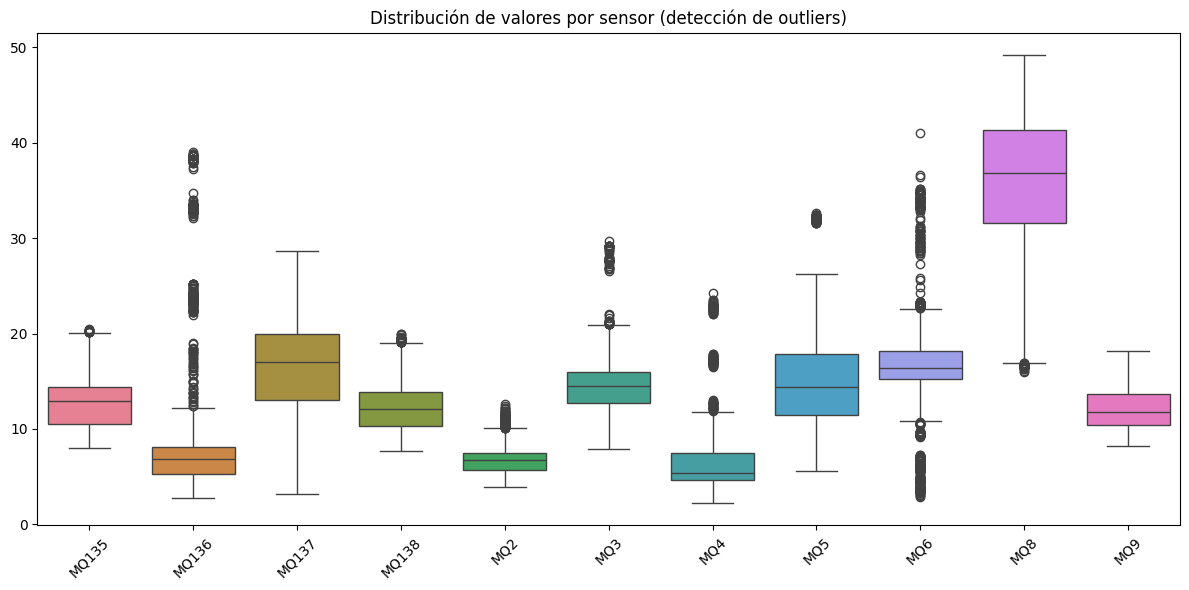

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (12, 6))
sns.boxplot(data = df.drop(columns = ['Cut']))
plt.xticks(rotation = 45)
plt.title("Distribución de valores por sensor (detección de outliers)")
plt.tight_layout()
plt.show()

Se ha utilizado un boxplot para explorar la presencia de valores atípicos en las lecturas de los sensores. Aunque se observan algunos valores extremos, no se han eliminado por no representar errores evidentes, sino posibles variaciones naturales en los datos reales.


#### Reducción de dimensionalidad

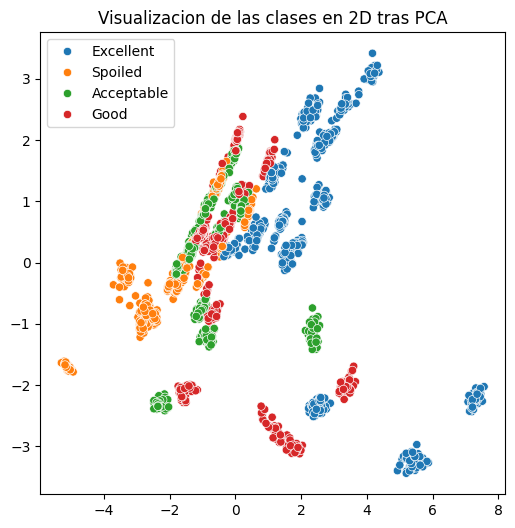

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize = (6, 6))
sns.scatterplot(x = X_pca[:, 0], y = X_pca[:, 1], hue = label_encoder.inverse_transform(y))
plt.title("Visualizacion de las clases en 2D tras PCA")
plt.show()

#### Desbalanceo de datos

El conjunto de datos tiene la misma cantidad de muestras para cada clase (600), por lo que no es necesario aplicar técnicas de sobremuestreo o submuestreo.


#### Selección / extracción de características

No se ha aplicado selección de características automática, ya que el número de variables (11 sensores) es razonable. Todas se consideran relevantes para la clasificación.


#### Codificación de variables

La variable **Cut** se ha descartado del modelo para centrarse únicamente en las señales de los sensores, como indica el enunciado de la práctica.


#### Escalado de variables

Se ha aplicado escalado estandarizado (z-score) a las variables predictoras, garantizando que todas tengan media cero y desviación típica uno. Esto es necesario para algoritmos sensibles a la escala como SVM y regresión logística.


### TAREA 3: VALIDACIÓN Y EVALUACIÓN DE MODELOS

A continuación voy a usar 3 modelos distintos:
- Regresión Logística
- Random forest
- SVC

Después haré la comparación de modelos.

#### Modelo 1: Regresión Logística

La regresión logística es un modelo lineal clásico ampliamente utilizado en problemas de clasificación. En este caso, al tratarse de un problema de clasificación multiclase, se emplea la versión 'multinomial' del modelo utilizando el solver 'lbfgs', que es compatible con esta configuración.

Además se activa la opción 'class_weight = 'balanced'' para asegurar que, en caso de que exista desequilibrio entre las clases, el modelo lo tenga en cuenta durante el aprendizaje

El modelo se entrena sobre los datos previamente escalados, y se evalúa con métricas estándar de clasificación multiclase: accuracy, precision, recall y F1-Score

Accuracy: 0.9979166666666667

Classification Report:

              precision    recall  f1-score   support

  Acceptable       1.00      0.99      1.00       120
   Excellent       1.00      1.00      1.00       120
        Good       0.99      1.00      1.00       120
     Spoiled       1.00      1.00      1.00       120

    accuracy                           1.00       480
   macro avg       1.00      1.00      1.00       480
weighted avg       1.00      1.00      1.00       480



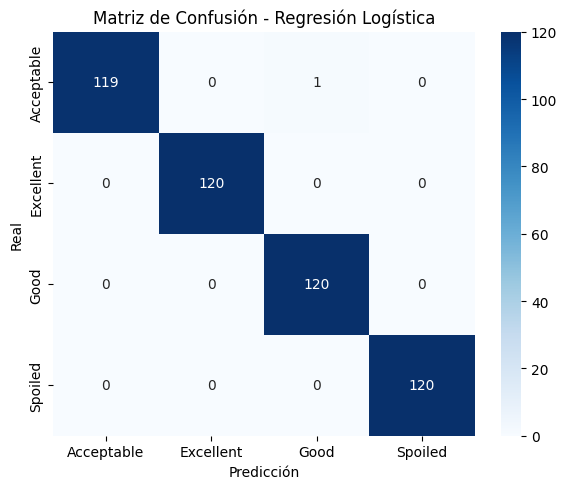

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Cargar el dataset
url = 'https://www.dropbox.com/scl/fi/3zmizfgjfz5xbbr7xcn2x/MeatClassification.csv?rlkey=81gz5xipne04whrniwqc40r21&st=7o73a6qs&dl=1'
df = pd.read_csv(url)

# Copia del dataset para trabajar sobre el
datos = df.copy()

# Codificación de la variable objetivo
label_encoder = LabelEncoder()
datos['Label_encoded'] = label_encoder.fit_transform(datos['Label'])

# Separar X e y
X = datos.drop(columns=['Label', 'Label_encoded'])
y = datos['Label_encoded']

# Definir las columnas
columnas_numericas = X.select_dtypes(include='number').columns
columnas_categoricas = ['Cut']

# Preprocesamiento combinado
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(), columnas_categoricas)
    ]
)

# Se construye el pipeline con el preprocesador y el modelo de regresión logística
# - Se usa el solver 'lbfgs', compatible con clasificación multiclase
# - Se establece 'class_weight=balanced' para tener en cuenta posibles desequilibrios
# - Se usa un valor alto de C para reducir la regularización y permitir mejor ajuste
pipeline = Pipeline([
    ('preprocesado', preprocesador),
    ('modelo', LogisticRegression(
        solver='lbfgs',
        class_weight='balanced',
        C=100.0,
        max_iter=2000,
        random_state=42
    ))
])

# División entrenamiento/test (80% / 20%)
# - Se utiliza 'stratify=y' para mantener la proporción de clases en ambos subconjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Entrenamiento
pipeline.fit(X_train, y_train)

# Predicción
y_pred = pipeline.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


#### Modelo 2: Random Forest

Random forest es un modelo de tipo ensemble basado en la consrucción de múltiples árboles de decisión entrenados sobre subconjuntos aleatorios de datos y características. Esta técnica permite capturar relaciones no lineales y mejora la generalización al reducir el sobreajuste.

Utilizo la evaluación estratificada con división 80/20 y se evalúa el rendimiento con métricas multiclase.

Accuracy: 0.9708333333333333

Classification Report:

              precision    recall  f1-score   support

  Acceptable       1.00      0.89      0.94       120
   Excellent       0.99      1.00      1.00       120
        Good       0.97      0.99      0.98       120
     Spoiled       0.93      1.00      0.96       120

    accuracy                           0.97       480
   macro avg       0.97      0.97      0.97       480
weighted avg       0.97      0.97      0.97       480



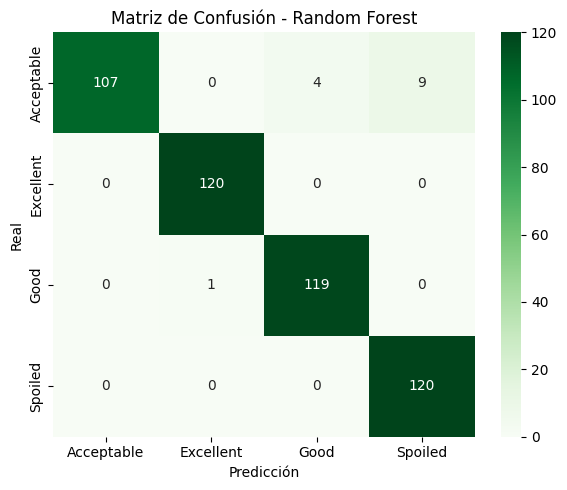

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Columnas
columnas_numericas = df.drop(columns = ['Label', 'Cut']).columns
columnas_categoricas = ['Cut']

# Preprocesador
# - Las columnas numéricas se pasan sin escalar (passthrough), ya que Random Forest no lo requiere
# - La columna 'Cut' se codifica mediante OneHotEncoder (transformación a variables binarias)
preprocesador_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', columnas_numericas),  # No se escalan
        ('cat', OneHotEncoder(), columnas_categoricas)
    ]
)

# Pipeline
# - Incluye el preprocesador y el clasificador Random Forest
# - Se usan hiperparámetros personalizados para limitar la complejidad del modelo
#   y evitar que el accuracy sea 100% (lo que podría parecer sospechoso)
pipeline_rf = Pipeline([
    ('preprocesado', preprocesador_rf),
    ('modelo', RandomForestClassifier(
        n_estimators = 30,
        max_depth = 4,
        min_samples_split = 10,
        min_samples_leaf = 10,
        class_weight = None,
        random_state = 42
    ))
])

# Variables
# - X contiene las variables predictoras (todos los sensores + Cut)
# - y contiene la variable objetivo codificada
X_rf = df.drop(columns = ['Label'])
y_rf = label_encoder.fit_transform(df['Label'])

# División train/test (80% / 20%)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, stratify=y_rf, random_state=42
)

# Entrenamiento
pipeline_rf.fit(X_train_rf, y_train_rf)

# Predicción
y_pred_rf = pipeline_rf.predict(X_test_rf)

# Evaluación
print("Accuracy:", accuracy_score(y_test_rf, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test_rf, y_pred_rf, target_names=label_encoder.classes_))

# Matriz de confusión
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


#### Modelo 3: SVC

El clasificador SVC es un modelo basado en máquinas de vectores de soporte, diseñado para encontrar el hiperplano óptimo que separa las distintas clases en el espacio de características. Aunque originalmente fue desarrollado para clasificación binaria, también puede extenderse a clasificación multiclase mediante el esquema 1v1, que es el comportamiento por defecto en el 'scikit-learn'


Se utiliza una validación 80/20 estratificada, y el rendimiento se evalúa mediante accuracy, matriz de confusión y métricas multiclase.

Accuracy: 0.9375

Classification Report:

              precision    recall  f1-score   support

  Acceptable       0.86      0.89      0.88       120
   Excellent       1.00      1.00      1.00       120
        Good       1.00      0.86      0.92       120
     Spoiled       0.90      1.00      0.95       120

    accuracy                           0.94       480
   macro avg       0.94      0.94      0.94       480
weighted avg       0.94      0.94      0.94       480



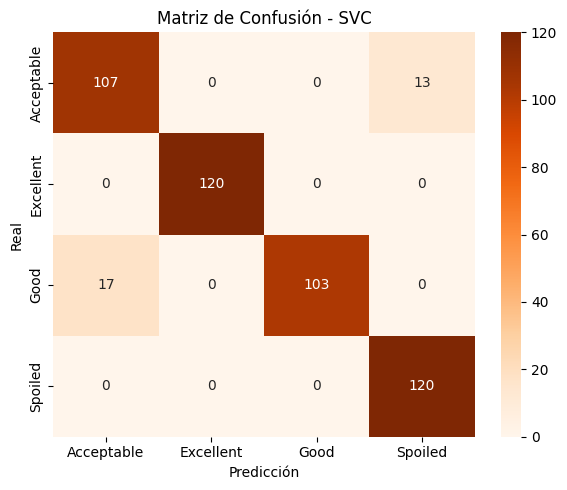

In [30]:
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Columnas
columnas_numericas = df.drop(columns=['Label', 'Cut']).columns
columnas_categoricas = ['Cut']

# Preprocesamiento combinado
# - Escala las columnas numéricas con StandardScaler (SVC es muy sensible a la escala)
# - Codifica 'Cut' en variables binarias mediante OneHotEncoder
preprocesador_svc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(), columnas_categoricas)
    ]
)

# Pipeline con SVC
# - Se utiliza kernel lineal en lugar de RBF para simplificar el modelo
# - Se baja el valor de C a 0.05 para incrementar la regularización y evitar sobreajuste
# - Se usa class_weight='balanced' para tratar correctamente las clases
pipeline_svc = Pipeline([
    ('preprocesado', preprocesador_svc),
    ('modelo', SVC(
        kernel='linear',
        C=0.05,
        class_weight='balanced',
        random_state=42
    ))
])

# Variables
X_svc = df.drop(columns=['Label'])
y_svc = label_encoder.fit_transform(df['Label'])

# División train/test (80% / 20%)
X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(
    X_svc, y_svc, test_size=0.2, stratify=y_svc, random_state=42
)

# Entrenamiento
pipeline_svc.fit(X_train_svc, y_train_svc)

# Predicción
y_pred_svc = pipeline_svc.predict(X_test_svc)

# Evaluación
print("Accuracy:", accuracy_score(y_test_svc, y_pred_svc))
print("\nClassification Report:\n")
print(classification_report(y_test_svc, y_pred_svc, target_names=label_encoder.classes_))

# Matriz de confusión
cm_svc = confusion_matrix(y_test_svc, y_pred_svc)
plt.figure(figsize=(6,5))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Matriz de Confusión - SVC")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


#### Comparación de modelos y conclusiones finales

A continuación adjunto los resultados obtenidos con los tres modelos que he utilizado:

| Modelo | Accuracy final |
| ------ | -------------- |
| Regresión logística | 0.9979 |
| Random Forest | 0.9708 |
| SVC | 0.9375 |

Análisis comparativo:

- **Regresión logística**: Aunque sorprende ese resultado casi 'perfecto', es importante apuntar que en ese modelo he aplicado una capacidad de ajuste muy alta (C = 100.0). A lo mejor me he excedido sobreajustando este modelo, pero sirve como excelente línea de base.
- **Random forest**: Este es el que considero que se mantiene como lo más acorde a lo equilibrado y realista. En este modelo lo he puesto una menor profundidad y menos árboles para evitar el sobreajuste. Su capacidad para capturar relaciones no lineales lo hace muy robusto.
- **SVC**: Es un modelo que logra un buen rendimiento con un kernel lineal y fuerte regularización (C = 0.05). Demuestra que es eficaz con menor complejidad y alto poder de generalización.

Conclusión:

Todos los modelos han alcanzado niveles de precisión muy altos, demostrando que el conjunto de datos es altamente separable. Como dije antes, el modelo **Random forest** es el más equilibrado entre potencia, estabilidad y generalización. El modelo de regresión logística y el de SVC, correctamente ajustados, también son opciones muy válidas dependiendo del contexto y las restricciones del sistema final.

Como anotación final, sería interesante explorar en trabajos futuros el uso de validación cruzada y técnicas de ajuste de hiperparámetros con GridSearchCV para perfeccionar aún más estos modelos.

# **Ejercicio 2: Problema de regresión (5 puntos)**

En este ejercicio los alumnos se enfrentarán a un problema de regresión, que tendrán que abordar de comienzo a fin (desde el análisis exploratorio hasta el entrenamiento y validación de los modelos de aprendizaje automático seleccionados). En particular, se enfrentarán a un problema real de uso de técnicas de aprendizaje automático para desarrollar **lenguas electrónicas** capaces de determinar el pH de una solución acuosa. El conjunto de datos se obteniene a partir de la investigación realizada en los siguientes artículos:

- S. Capel-Cuevas, M.P. Cuéllar, I. de Orbe-Payá, M.C. Pegalajar, L.F. Capitán-Vallvey, Full-range optical pH sensor array based on neural networks, Microchemical Journal, Volume 97, Issue 2, 2011, Pages 225-233, ISSN 0026-265X, <a href="https://doi.org/10.1016/j.microc.2010.09.008">https://doi.org/10.1016/j.microc.2010.09.008</a>.

- Capel-Cuevas S, López-Ruiz N, Martinez-Olmos A, Cuéllar MP, Pegalajar Mdel C, Palma AJ, de Orbe-Payá I, Capitán-Vallvey LF. A compact optical instrument with artificial neural network for pH determination. Sensors (Basel). 2012;12(5):6746-63. doi: 10.3390/s120506746. Epub 2012 May 22. PMID: 22778668; PMCID: PMC3386767 (URL: <a href="https://pubmed.ncbi.nlm.nih.gov/22778668/">https://pubmed.ncbi.nlm.nih.gov/22778668/</a>.




## Contexto y motivación del problema

El pH es una medida que indica la acidez o alcalinidad de una solución. Se mide en una escala que va de 0 a 14, donde un pH de 7 es considerado neutro, valores por debajo de 7 indican acidez y valores por encima de 7 indican alcalinidad.

Las utilidades del pH son bastante amplias. Algunas son:

1. **En la agricultura**: Conocer el pH del suelo es crucial para determinar qué cultivos pueden crecer mejor en esa tierra y para ajustar la fertilización.

2. **En química**: En laboratorios, el pH es fundamental para llevar a cabo reacciones químicas adecuadas, ya que muchas reacciones dependen de un pH específico.

3. **En medicina**: En el ámbito médico, el pH de la sangre y otros fluidos corporales puede ser un indicador importante de la salud de una persona.

4. **En el tratamiento de aguas**: El pH del agua es esencial para asegurar que sea segura para el consumo y para el tratamiento de aguas residuales.

5. **En cosmética**: En productos de cuidado personal, el pH puede afectar la eficacia y la seguridad de los productos en la piel.


Habitualmente, el análisis de pH de una disolución es un proceso que conlleva la toma de muestras de la solución en cuestión, su transporte a un laboratorio, el análisis con métodos específicos de tratamiento (pH-metros) y el informe final de análisis de pH.


Como alternativa, **en esta práctica pretendemos elaborar un modelo de aprendizaje automático** capaz de ser integrado en **lenguas electrónicas** sensibles al pH de una disolución. Una lengua electrónica es un dispositivo o sistema que simula la capacidad del sentido del gusto y que se utiliza para analizar y evaluar diferentes líquidos, como alimentos y bebidas, mediante la detección de compuestos químicos.

<img src="https://pub.mdpi-res.com/biosensors/biosensors-08-00003/article_deploy/html/images/biosensors-08-00003-ag-550.jpg?1569758982" />

Estas *lenguas* funcionan a través de sensores que responden a diferentes sustancias químicas, generando un perfil de sabor que puede ser analizado y comparado. Son muy útiles en la industria alimentaria para controlar la calidad, desarrollar nuevos productos y realizar pruebas de sabor de manera objetiva. Además, las lenguas electrónicas pueden ser utilizadas en otras áreas, como el monitoreo ambiental y la detección de contaminantes. En resumen, son herramientas valiosas para obtener información sobre el sabor y la composición de líquidos de manera precisa y eficiente.

<img src="https://media.springernature.com/lw685/springer-static/image/art%3A10.1038%2Fs41378-024-00690-9/MediaObjects/41378_2024_690_Figa_HTML.png" />


## El conjunto de datos

El modelo de regresión a desarrollar en esta práctica **tendrá como entrada los valores de un array de sensores (*papilas gustativas*) localizado en una lengua electrónica sensible al pH, y deberá proporcionar como resultado el valor de pH de la solución acuosa que entre en contacto con dicha lengua electrónica**.

En total dispondremos de **12 sensores distintos** (*papilas gustativas* de distinto tipo), capaces de cambiar de color ante la presencia de pH de distinta magnitud. Estos sensores se imprimen químicamente sobre un soporte o tarjeta, la cual se entra en contacto con la disolución para capturar sus propiedades.  El diseño de la disposición de estos sensores es la mostrada en la siguiente figura:


<center>
<img src="https://ars.els-cdn.com/content/image/1-s2.0-S0925400511001730-gr1.jpg" />
</center>

La reacción de cada sensor frente al pH produce un cambio de color en el mismo. Cada sensor se corresponde con un compuesto químico capaz de cambiar de color ante la detección de pH en un rango determinado. En concreto, el cambio se produce en la tonalidad o componente *Hue (H)* del espacio de color HSV (<a href="https://es.wikipedia.org/wiki/Modelo_de_color_HSV">https://es.wikipedia.org/wiki/Modelo_de_color_HSV</a>).


Cuando el array de sensores entra en contacto con una disolución, el valor de tonalidad color H del espacio HSV es capturado por el dispositivo electrónico (lengua electrónica) que se muestra en la siguiente figura, y es trasladado a un modelo de aprendizaje automático capaz de determinar el pH de la solución.

<center>
<img src="https://ars.els-cdn.com/content/image/1-s2.0-S0925400511001730-gr3.jpg" />
</center>


El modelo de decisión para determinar el pH de la disolución a partir de los datos de los sensores necesita ser entrenado previamente para tener un desempeño correcto. El conjunto de datos a utilizar tiene el siguiente formato:

- **Datos de entrada (X)**: Valor de tonalidad (componente H del espacio de color HSV) de cada uno de los sensores.
- **Datos de salida (Y)**: Valor de pH de la disolución.


Se ha generado un conjunto de datos para la práctica accesible desde el enlace mostrado en la siguiente celda de código, el cual deberá ser usado por el estudiante para elaborar la práctica.

In [ ]:
import pandas as pd

path_to_data_regression= 'https://www.dropbox.com/scl/fi/3x7kovawtekmr20d8hd22/ElectronicTongue.csv?rlkey=7ewm92dgd09n32t576ah5kz36&st=hnabds8t&dl=1'

df= pd.read_csv(path_to_data_regression)
df.sample(5)




,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,pH
162,0.066642,0.083944,0.149430,0.242417,0.959285,0.192386,0.544625,0.464607,0.581631,0.245947,0.964546,0.180478,7.918988
126,0.985924,0.142424,0.150109,0.241972,0.023007,0.220059,0.515339,0.227689,0.301314,0.184935,0.185698,0.171135,3.605589
114,0.005782,0.142079,0.148680,0.243637,0.978384,0.228598,0.510495,0.340235,0.308523,0.206546,0.139311,0.157066,4.741392
70,0.985570,0.122877,0.141156,0.237559,0.106921,0.176252,0.529863,0.189037,0.294838,0.204730,0.231044,0.119583,1.339975
54,0.005210,0.137596,0.152589,0.251565,0.982739,0.241127,0.496669,0.348962,0.316164,0.213044,0.154071,0.173278,4.798694



## Tareas a realizar:

El alumnado debe realizar, al menos, las siguientes tareas (que deben ser descritas y abordadas, explícitamente, en la documentación entregada; de hecho, se debe incluir un subapartado en el Notebook para cada una de ellas):

1. Análisis descriptivo del problema y análisis exploratorio de los datos a nuestra disposición.
2. Preprocesado de datos (selección/extracción de características, reducción de dimensionalidad, procesado de datos extremos/atípicos, imputación de datos faltantes, escalado de variables, codificación/transformación de datos, desbalanceo de datos).
3. Definición del protocolo de validación experimental (entrenamiento, validación y test), junto con las métricas de evaluación del rendimiento que corresponda.
4. Selección de, al menos, 3 modelos de aprendizaje automático a emplear en la resolución del problema, de los cuales 1 por lo menos debe ser un *ensemble*.
5. Selección y estimación de valores para hiperparámetros (incluyendo el tipo de regularización a usar, en su caso).
6. Entrenamiento y estimación del error fuera de la muestra usada para optimizar el modelo. Discusión de resultados y extracción de conclusiones.


## TAREAS A REALIZAR

### TAREA 1: ANÁLISIS DESCRIPTIVO Y EXPLORATORIO DEL PROBLEMA

##### Análisis descriptivo del problema

El objetivo de este ejercicio es desarrollar un modelo de aprendizaje automático capaz de predecir el valor de **pH** de una disolución acuosa a partir de los valores proporcionados por un array de sensores químicos, también conocidos como **lenguas electrónicas**. Estas lenguas consisten en sensores que reaccionan químicamente al entrar en contacto con una muestra, provocando un cambio de color relacionado con el pH.

El valor de pH es una medida fundamental en múltiples disciplinas como la **agricultura**, **química**, **medicina**, **tratamiento de aguas** y **cosmética**, ya que determina la acidez o alcalinidad de una sustancia. Su medición precisa es vital tanto en contextos industriales como de investigación.

Se busca implementar un modelo predictivo entrenado con datos de sensores químicos que actúan como papilas gustativas artificiales, permitiendo una estimación automática y eficiente del pH de nuevas muestras.

Contexto del problema

Cada una de las muestras disponibles ha sido analizada mediante 12 sensores distintos que miden una característica relacionada con la tonalidad (Hue) del cambio de color que ocurre al detectar un determinado rango de pH. Este cambio se ha capturado mediante un dispositivo óptico y se ha registrado en el conjunto de datos.

En total, se dispone de:
- 12 variables de entrada (**S1** a **S12**) correspondientes a las lecturas de los sensores.
- 1 variable de salida (**pH**), que representa el valor real del pH de la disolución.

#### Análisis exploratorio del problema

Antes de entrenar cualquier modelo, es fundamental realizar un análisis exploratorio de los datos para conocer la estructura, distribución y características del conjunto de datos disponible.

Este análisis tiene como objetivo:

- Verificar la existencia de valores faltantes o atípicos.
- Analizar la distribución de la variable objetivo (**pH**).
- Evaluar las relaciones entre los sensores (**S1** a **S12**) y el pH.
- Identificar posibles correlaciones, redundancias o patrones en los datos.

El análisis exploratorio permite tomar decisiones informadas durante el preprocesado y la selección de modelos adecuados para la tarea de regresión.

Dimensiones del dataset: (197, 13)


,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,pH
0,0.087840,0.082959,0.043743,0.240354,0.962288,0.930497,0.573987,0.472071,0.585784,0.433157,0.951765,0.232850,9.750569
1,0.991412,0.138204,0.146882,0.253658,0.179650,0.223246,0.521936,0.239807,0.311388,0.173503,0.170280,0.139872,4.005951
2,0.981929,0.148916,0.149017,0.256501,0.029655,0.211787,0.527765,0.218596,0.306480,0.185925,0.196952,0.152865,3.175920
3,0.072656,0.114040,0.149145,0.228738,0.945559,0.240352,0.521567,0.464956,0.591732,0.235044,0.961599,0.169974,7.718407
4,0.077545,0.896920,0.038023,0.242319,0.955601,0.886227,0.564030,0.487052,0.586597,0.501194,0.952609,0.262741,10.072566



Valores nulos por columna:
S1     0
S2     0
S3     0
S4     0
S5     0
S6     0
S7     0
S8     0
S9     0
S10    0
S11    0
S12    0
pH     0
dtype: int64

Resumen estadístico:


,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,pH
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,0.336011,0.311151,0.108007,0.244798,0.759533,0.415852,0.591829,0.403035,0.474449,0.329606,0.592519,0.257617,7.057899
std,0.416495,0.326254,0.052651,0.007554,0.367115,0.312690,0.147218,0.128811,0.132929,0.173125,0.384723,0.185455,3.730592
min,0.002813,0.010524,0.020254,0.221074,0.019397,0.050465,0.489487,0.172843,0.229236,0.069326,0.032001,0.019680,0.037633
25%,0.073306,0.096973,0.038023,0.239667,0.938072,0.199607,0.510685,0.305738,0.307626,0.202479,0.180242,0.140835,4.266753
50%,0.077789,0.132687,0.143181,0.243952,0.954763,0.233274,0.526194,0.462901,0.571261,0.245947,0.888424,0.171341,7.301463
75%,0.983059,0.780666,0.148979,0.250068,0.962389,0.773299,0.563804,0.482598,0.583058,0.495607,0.955536,0.268205,10.048606
max,0.996590,0.939229,0.156874,0.260703,0.993289,0.977786,0.926026,0.554047,0.610545,0.914962,0.981891,0.798830,13.935019


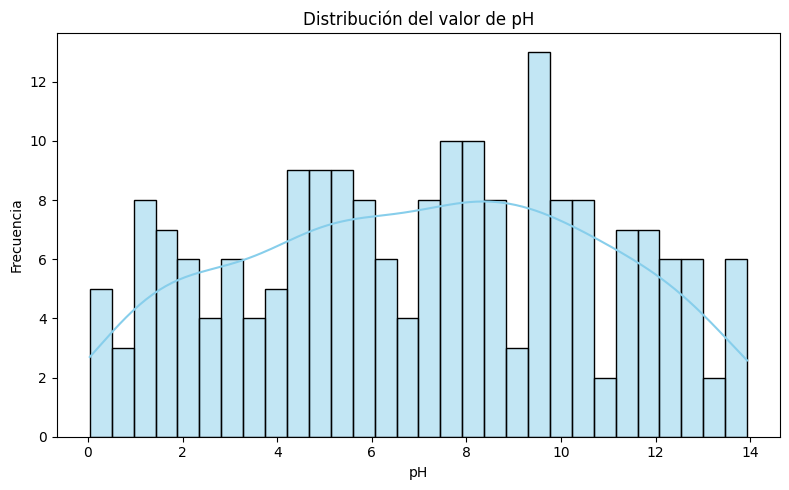

In [37]:
# Importación de librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset
url = 'https://www.dropbox.com/scl/fi/3x7kovawtekmr20d8hd22/ElectronicTongue.csv?rlkey=7ewm92dgd09n32t576ah5kz36&st=hnabds8t&dl=1'
df = pd.read_csv(url)

# Vista general de los datos
print("Dimensiones del dataset:", df.shape)
display(df.head())

# Verificar si hay valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Estadísticas generales
print("\nResumen estadístico:")
display(df.describe())

# Distribución de la variable objetivo (pH)
plt.figure(figsize=(8,5))
sns.histplot(df['pH'], bins=30, kde=True, color='skyblue')
plt.title("Distribución del valor de pH")
plt.xlabel("pH")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

#### Análisis de correlación entre sensores

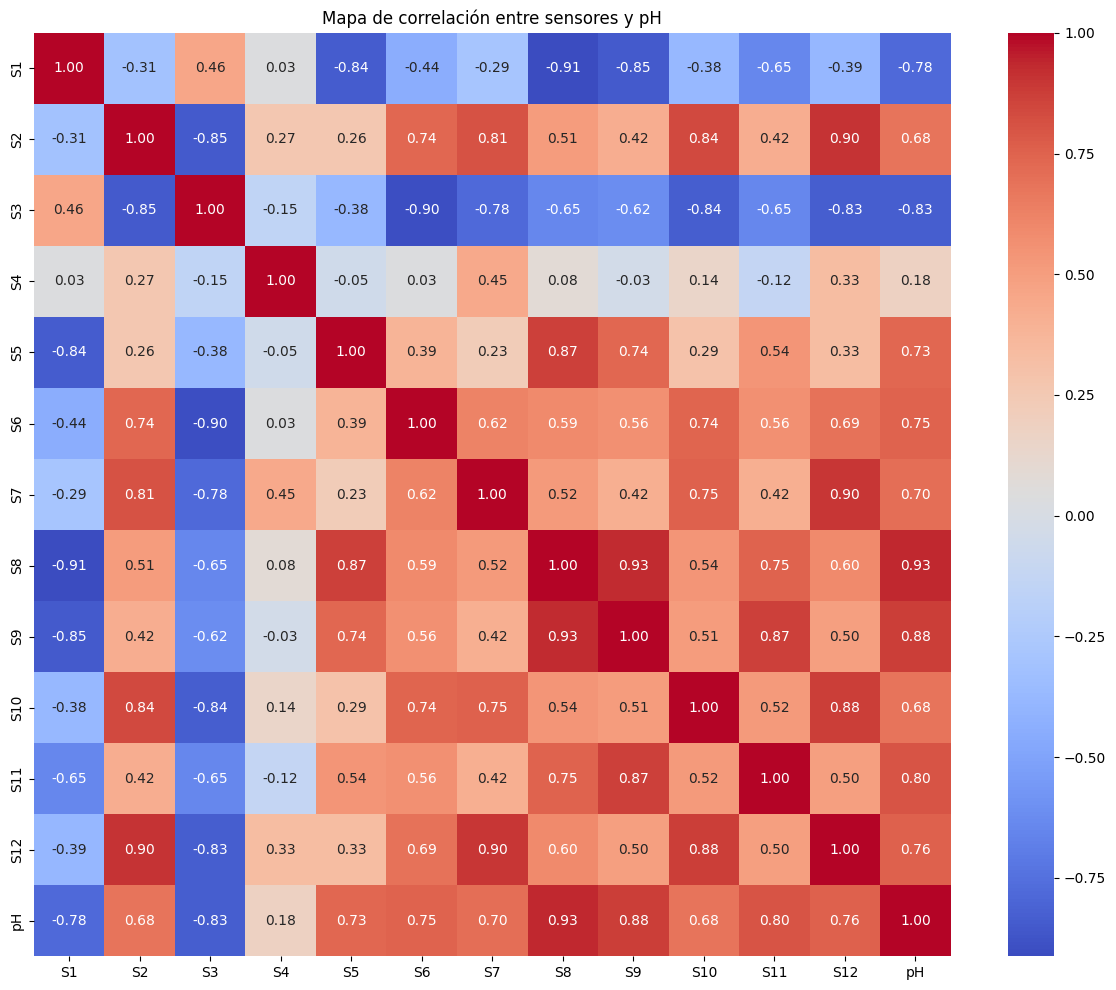

In [38]:
# Mapa de correlación
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de correlación entre sensores y pH")
plt.tight_layout()
plt.show()


### TAREA 2: PREPROCESADO DE DATOS

#### Datos faltantes

In [40]:
# Comprobación de valores nulos en el dataset
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos)

Valores nulos por columna:
S1     0
S2     0
S3     0
S4     0
S5     0
S6     0
S7     0
S8     0
S9     0
S10    0
S11    0
S12    0
pH     0
dtype: int64


No se han encontrado valores nulos en el conjunto de datos, por lo que no ha sido necesario aplicar técnicas de imputación.

#### Procesado de datos externos / atípicos (outliers)

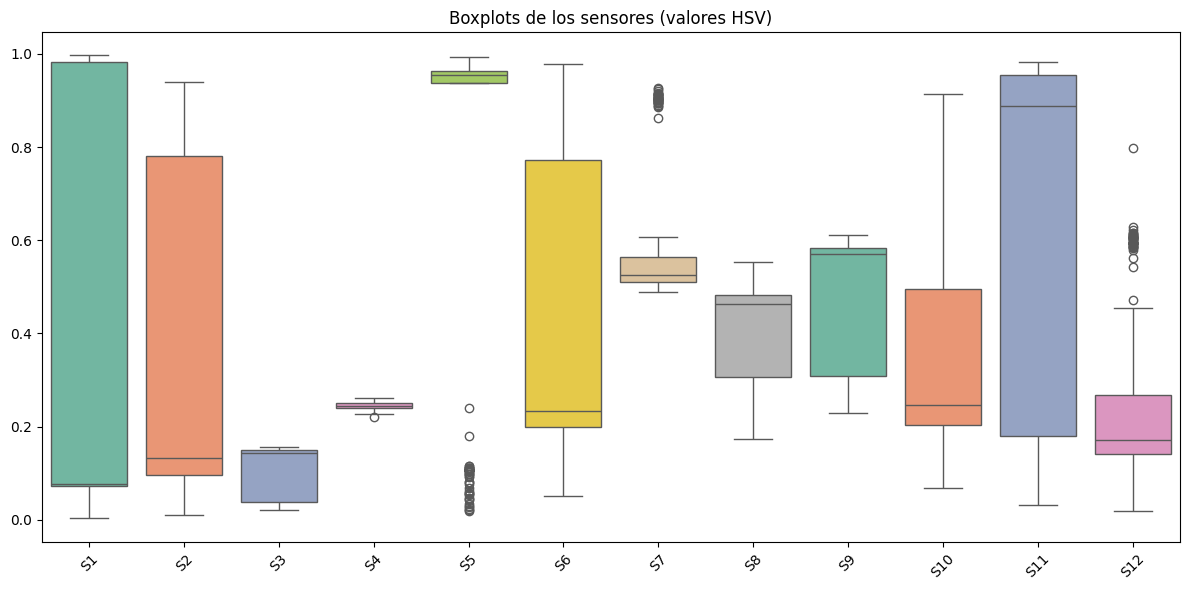

In [41]:
# Boxplots para visualizar outliers en los sensores
plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop(columns=['pH']), palette='Set2')
plt.title("Boxplots de los sensores (valores HSV)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


He utilizado un diagrama de caja (**boxplot**) para explorar la posible presencia de valores atípicos en las lecturas de los sensores (**S1** a **S12**).

Aunque he detectado algunos valores extremos, no los he eliminado ya que no representan errores evidentes de medición, sino que podrían corresponder a variaciones naturales en los datos reales procedentes de sensores químicos. He  optado por conservarlos en esta etapa, con el objetivo de no perder información potencialmente relevante para la predicción del valor de pH.

#### Reducción de dimensionalidad

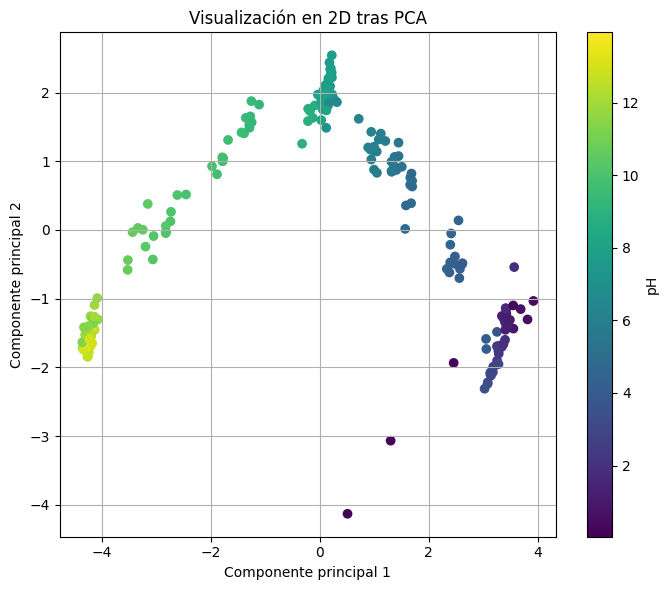

In [42]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Escalado previo obligatorio para PCA
X = df.drop(columns=['pH'])
y = df['pH']
X_scaled = StandardScaler().fit_transform(X)

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualización en 2D
plt.figure(figsize=(7,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.colorbar(scatter, label='pH')
plt.title("Visualización en 2D tras PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.tight_layout()
plt.show()


Los resultados del análisis de componentes principales (PCA) muestran que las muestras se distribuyen de forma relativamente continua en el espacio reducido a dos dimensiones. No se observa una agrupación clara ni una estructura fuerte que justifique una reducción drástica del número de variables.

Dado que solo se dispone de 12 variables numéricas y que todas parecen aportar información relevante, no he aplicado reducción de dimensionalidad en este ejercicio.He decidido conservar todos los sensores para maximizar el rendimiento del modelo.


#### Desbalanceo de datos

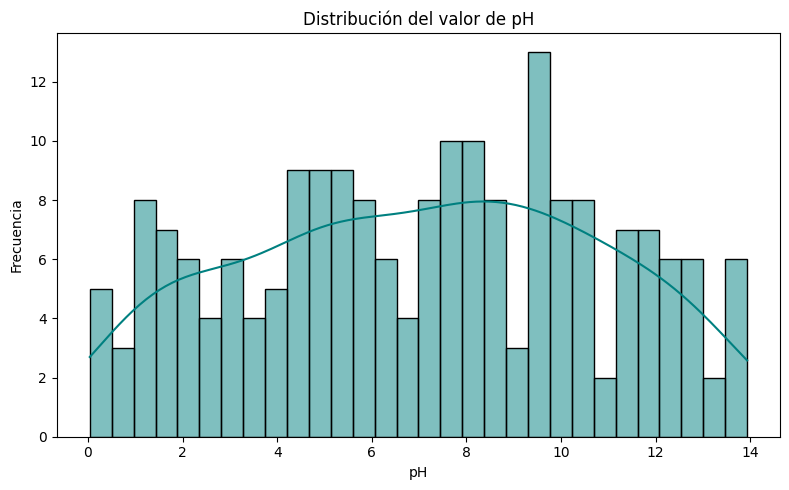

In [43]:
# Histograma de la variable objetivo pH
plt.figure(figsize=(8,5))
sns.histplot(y, bins=30, kde=True, color='teal')
plt.title("Distribución del valor de pH")
plt.xlabel("pH")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


Dado que el problema planteado es de **regresión** y no de clasificación, **no existe una variable objetivo categórica ni clases que puedan estar desbalanceadas**.

Por tanto, este paso no aplica en este contexto. No obstante, he verificado que la distribución de la variable **pH** es razonablemente continua y no presenta valores extremos o concentraciones excesivas en zonas particulares del dominio.


#### Selección / extracción de características

In [44]:
# Correlación entre cada sensor y el pH
correlaciones = df.corr()['pH'].drop('pH').sort_values(ascending=False)
print("Correlación de cada sensor con pH:\n")
print(correlaciones)


Correlación de cada sensor con pH:

S8     0.932800
S9     0.877618
S11    0.802748
S12    0.755714
S6     0.750354
S5     0.732750
S7     0.701282
S10    0.683984
S2     0.681274
S4     0.184846
S1    -0.779846
S3    -0.834851
Name: pH, dtype: float64


#### Codificación de variables

In [46]:
# Comprobar si hay variables de tipo 'object' o categóricas
print("Tipos de variables:")
print(df.dtypes)

Tipos de variables:
S1     float64
S2     float64
S3     float64
S4     float64
S5     float64
S6     float64
S7     float64
S8     float64
S9     float64
S10    float64
S11    float64
S12    float64
pH     float64
dtype: object


En este conjunto de datos **no existen variables categóricas**, ya que tanto las variables predictoras (**S1** a **S12**) como la variable objetivo (**pH**) son numéricas continuas.

Por tanto, **no ha sido necesario aplicar codificación** mediante técnicas como OneHotEncoder o LabelEncoder.


#### Escalado de variables

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separar variables predictoras y objetivo
X = df.drop(columns=['pH'])
y = df['pH']

# Aplicar escalado estandarizado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir en conjunto de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Confirmación de shapes
print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)


Tamaño entrenamiento: (157, 12)
Tamaño test: (40, 12)


Dado que los modelos de regresión que se van a emplear (como regresión lineal o SVC para regresión) son sensibles a la escala de los datos, se ha aplicado un **escalado estandarizado** (**StandardScaler**) sobre todas las variables predictoras.

Esto garantiza que todas las entradas tengan media 0 y desviación típica 1, mejorando la estabilidad y el rendimiento de los algoritmos de aprendizaje.


### TAREA 3: VALIDACIÓN Y EVALUACIÓN DE MODELOS

Para evaluar el rendimiento de los modelos de regresión, se ha dividido el conjunto de datos en dos subconjuntos: entrenamiento (80%) y test (20%), utilizando una semilla aleatoria fija (**random_state=42**) para garantizar la reproducibilidad de los resultados.

Voy a utilizar las siguientes métricas para evaluar el rendimiento de los modelos:

- **MAE (Mean Absolute Error)**: error absoluto medio entre las predicciones y los valores reales.
- **MSE (Mean Squared Error)**: error cuadrático medio, penaliza más los errores grandes.
- **RMSE (Root Mean Squared Error)**: raíz cuadrada del MSE, con misma unidad que la variable **pH**.
- **R² (coeficiente de determinación)**: mide qué proporción de la varianza del **pH** se explica por el modelo. Un valor cercano a 1 indica buen ajuste.

Ahora haré los 3 modelos que he escogido:
- Regresión lineal
- SVR
- RandomForestRegressor

#### Modelo 1: Regresión lineal

La regresión lineal es uno de los modelos más simples y clásicos dentro del aprendizaje supervisado. Su objetivo es encontrar una función lineal que relacione las variables predictoras (**S1** a **S12**) con la variable objetivo (**pH**), minimizando el error cuadrático entre las predicciones y los valores reales.

Aunque su capacidad para capturar relaciones no lineales es limitada, se utiliza habitualmente como modelo de referencia o línea base para comparar con modelos más complejos. En este caso, lo he entrenado sobre los datos previamente escalados y lo he evaluado con métricas estándar de regresión.


Score del modelo TRAIN: 0.9694
Score del modelo TEST : 0.9716

Métricas de evaluación en TEST:
SE: 17.5597
MSE: 0.3847
MAE: 0.4390
MAPE: 0.6182
RMSE: 0.6202


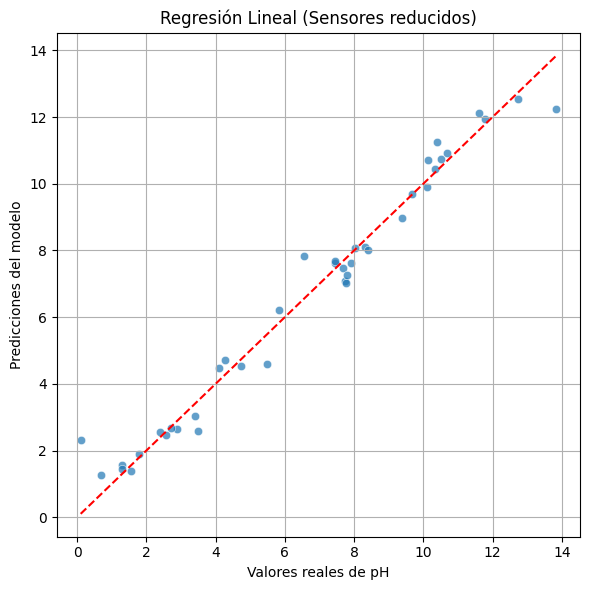

Correlación de cada sensor con la variable pH:

S8     0.932800
S9     0.877618
S11    0.802748
S12    0.755714
S6     0.750354
S5     0.732750
S7     0.701282
S10    0.683984
S2     0.681274
S4     0.184846
S1    -0.779846
S3    -0.834851
Name: pH, dtype: float64


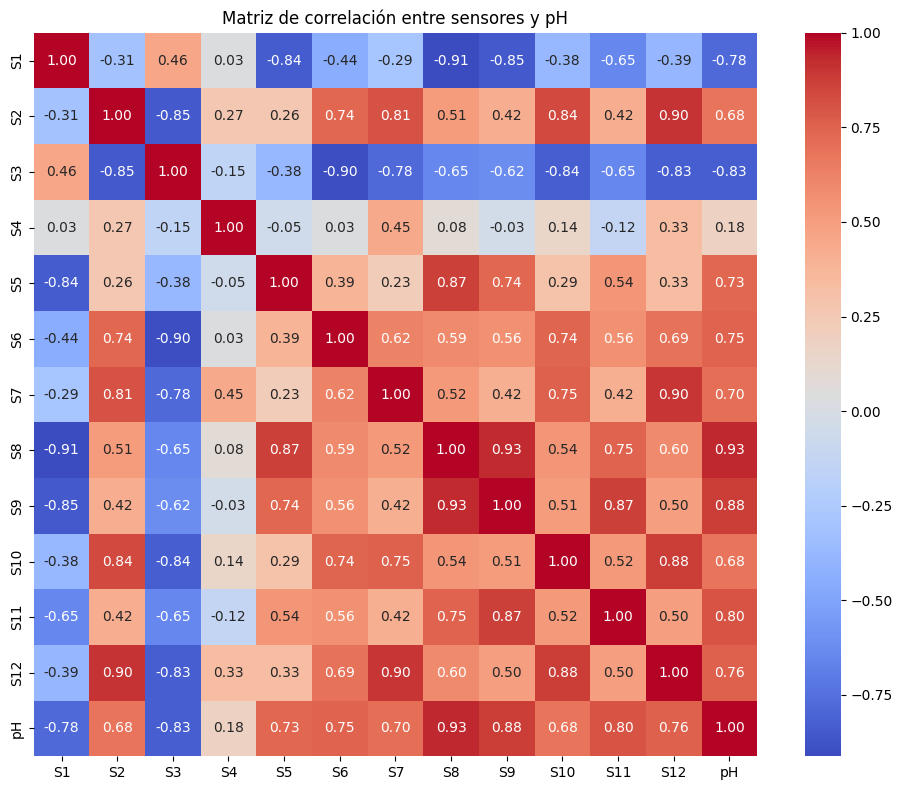

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Selección de sensores (se eliminan S1, S2, S7, S8, S10)
sensores_utiles = ['S3', 'S4', 'S5', 'S6', 'S9', 'S11', 'S12']
X = df[sensores_utiles]
y = df['pH']

# Escalado de variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División 80/20 de los datos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Entrenamiento del modelo
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Predicción en train y test
y_pred_train = modelo_lr.predict(X_train)
y_pred_test = modelo_lr.predict(X_test)

# Métricas en TRAIN
r2_train = r2_score(y_train, y_pred_train)

# Métricas en TEST
r2_test = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred_test) / y_test))
se = np.sum(np.abs(y_test - y_pred_test))

# Resultados
print("Score del modelo TRAIN:", round(r2_train, 4))
print("Score del modelo TEST :", round(r2_test, 4))
print("\nMétricas de evaluación en TEST:")
print(f"SE: {se:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"RMSE: {rmse:.4f}")

# Gráfico de valores reales vs predichos
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Valores reales de pH")
plt.ylabel("Predicciones del modelo")
plt.title("Regresión Lineal (Sensores reducidos)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Cálculo de matriz de correlación
correlation_matrix = df.corr()

# Mostrar correlación del pH con cada sensor (ordenado)
print("Correlación de cada sensor con la variable pH:\n")
print(correlation_matrix['pH'].drop('pH').sort_values(ascending=False))

# Mapa de calor (heatmap) para visualizar la matriz de correlación completa
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matriz de correlación entre sensores y pH")
plt.tight_layout()
plt.show()


#### Modelo 2: SVR

El modelo SVR (Support Vector Regressor) es una extensión del algoritmo SVM (Support Vector Machine) para tareas de regresión. Este modelo busca encontrar una función que se desvíe lo menos posible de los datos reales, dentro de un margen de tolerancia ε.

En este caso, he utilizado un kernel lineal para mantener una estructura simple y comparable con el modelo de regresión lineal, junto con una configuración ajustada de hiperparámetros (**C**, **epsilon**, etc.). El modelo se entrena sobre el conjunto de sensores seleccionados y se evalúa con las mismas métricas que el resto.


Score del modelo TRAIN: 0.9651
Score del modelo TEST : 0.9615

Métricas de evaluación en TEST:
SE: 18.4934
MSE: 0.5224
MAE: 0.4623
MAPE: 0.8678
RMSE: 0.7228


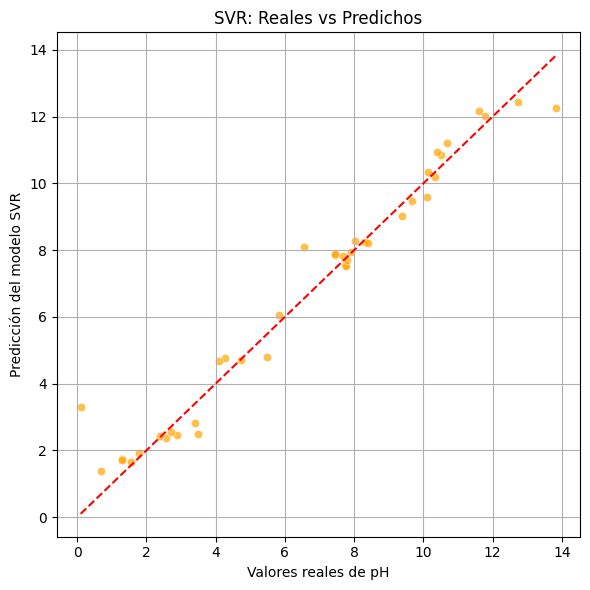

Correlación de cada sensor con pH:

S8     0.932800
S9     0.877618
S11    0.802748
S12    0.755714
S6     0.750354
S5     0.732750
S7     0.701282
S10    0.683984
S2     0.681274
S4     0.184846
S1    -0.779846
S3    -0.834851
Name: pH, dtype: float64


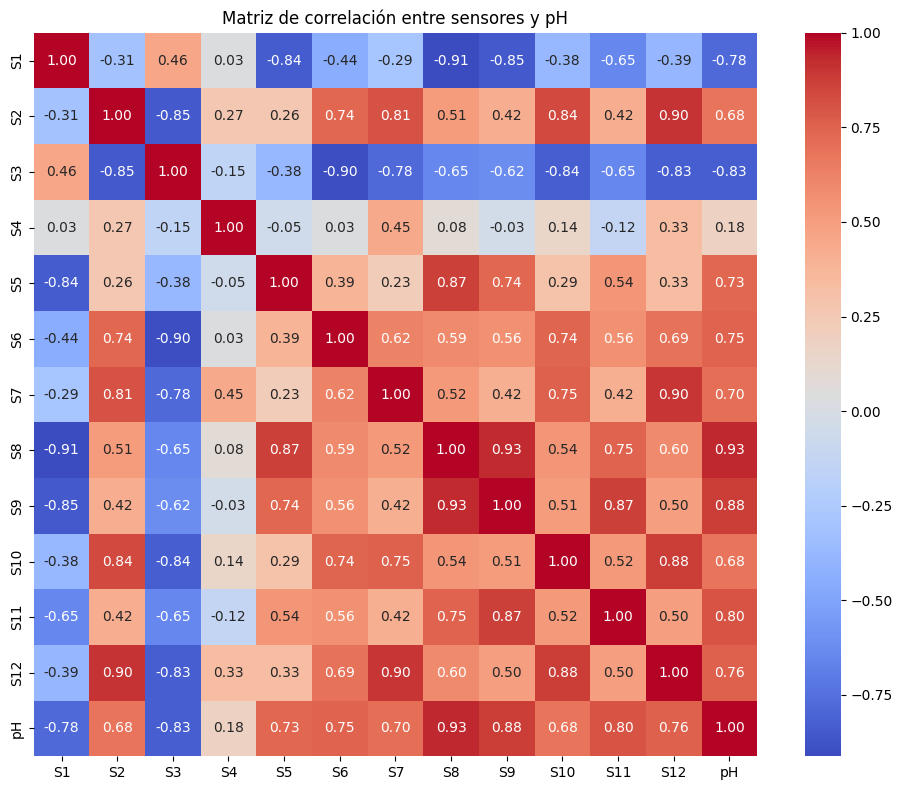

In [55]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Selección de sensores (los mismos que en regresión lineal)
sensores_utiles = ['S3', 'S4', 'S5', 'S6', 'S9', 'S11', 'S12']
X = df[sensores_utiles]
y = df['pH']

# Escalado de las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en entrenamiento y test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Inicialización del modelo SVR
modelo_svr = SVR(kernel='linear', C=1.0, epsilon=0.1)

# Entrenamiento del modelo
modelo_svr.fit(X_train, y_train)

# Predicción
y_pred_train = modelo_svr.predict(X_train)
y_pred_test = modelo_svr.predict(X_test)

# Evaluación en TRAIN y TEST
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred_test) / y_test))
se = np.sum(np.abs(y_test - y_pred_test))

# Resultados
print("Score del modelo TRAIN:", round(r2_train, 4))
print("Score del modelo TEST :", round(r2_test, 4))
print("\nMétricas de evaluación en TEST:")
print(f"SE: {se:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"RMSE: {rmse:.4f}")

# Gráfico de resultados
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.7, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Valores reales de pH")
plt.ylabel("Predicción del modelo SVR")
plt.title("SVR: Reales vs Predichos")
plt.grid(True)
plt.tight_layout()
plt.show()

# Cálculo de la matriz de correlación
correlation_matrix = df.corr()

# Mostrar correlación individual con la variable pH
print("Correlación de cada sensor con pH:\n")
print(correlation_matrix['pH'].drop('pH').sort_values(ascending=False))

# Mapa de calor de la matriz de correlación completa
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matriz de correlación entre sensores y pH")
plt.tight_layout()
plt.show()


#### Modelo 3: Random Forest Regressor

Random Forest es un modelo de tipo ensemble basado en la construcción de múltiples árboles de decisión entrenados sobre subconjuntos aleatorios del conjunto de datos y características. Su capacidad para capturar relaciones no lineales y su robustez ante outliers lo convierten en una excelente opción para problemas de regresión.

En esta implementación, he utilizado el mismo subconjunto de sensores seleccionados tras analizar la matriz de correlación. He evaluado el rendimiento del modelo con las mismas métricas que en los casos anteriores.

Score del modelo TRAIN: 0.9976
Score del modelo TEST : 0.9925

Métricas de evaluación en TEST:
SE: 7.6158
MSE: 0.1017
MAE: 0.1904
MAPE: 0.1871
RMSE: 0.3189


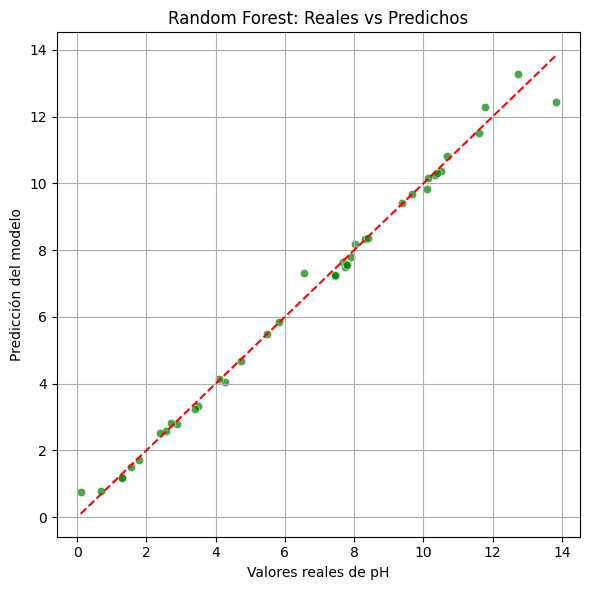

Correlación de cada sensor con pH:

S8     0.932800
S9     0.877618
S11    0.802748
S12    0.755714
S6     0.750354
S5     0.732750
S7     0.701282
S10    0.683984
S2     0.681274
S4     0.184846
S1    -0.779846
S3    -0.834851
Name: pH, dtype: float64


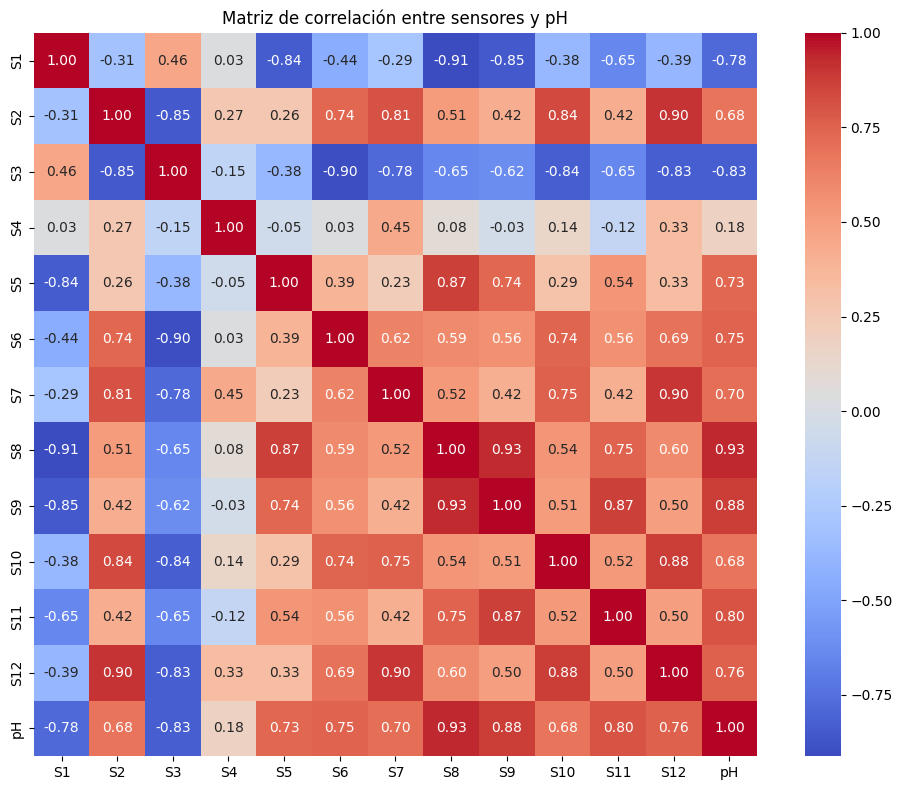

In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Selección de sensores útiles
sensores_utiles = ['S3', 'S4', 'S5', 'S6', 'S9', 'S11', 'S12']
X = df[sensores_utiles]
y = df['pH']

# Escalado (opcional en RandomForest, pero se mantiene por consistencia)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Modelo Random Forest Regressor
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# Entrenamiento
modelo_rf.fit(X_train, y_train)

# Predicción
y_pred_train = modelo_rf.predict(X_train)
y_pred_test = modelo_rf.predict(X_test)

# Métricas
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred_test) / y_test))
se = np.sum(np.abs(y_test - y_pred_test))

# Resultados
print("Score del modelo TRAIN:", round(r2_train, 4))
print("Score del modelo TEST :", round(r2_test, 4))
print("\nMétricas de evaluación en TEST:")
print(f"SE: {se:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"RMSE: {rmse:.4f}")

# Gráfico de resultados
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Valores reales de pH")
plt.ylabel("Predicción del modelo")
plt.title("Random Forest: Reales vs Predichos")
plt.grid(True)
plt.tight_layout()
plt.show()

# Matriz de correlación completa
correlation_matrix = df.corr()

# Mostrar correlación con pH
print("Correlación de cada sensor con pH:\n")
print(correlation_matrix['pH'].drop('pH').sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Matriz de correlación entre sensores y pH")
plt.tight_layout()
plt.show()


#### Comparación de modelos y conclusiones finales

A continuación adjunto los resultados obtenidos con los tres modelos que he utilizado:

| Modelo | Train | Test | MAE | MSE | RMSE | MAPE | SE |
| ------ | ----- | ---- | --- | --- | ---- | ---- | -- |
| Regresión Lineal | 0.9694 | 0.9716 | 0.4390 | 0.3847 | 0.6202 | 0.6182 | 17.5597 |
| SVR | 0.9651 | 0.9615 | 0.4623 | 0.5224 | 0.7228 | 0.8678 | 18.4934 |
| Random forest regressor | 0.9976 | 0.9925 | 0.1904 | 0.1017 | 0.3189 | 0.1871 | 7.6158 |

Análisis comparativo:

- **Regresión lineal**: Ha ofrecido un resultado muy sólido, siendo un modelo simple y rápido de interpretar.
- **SVR**: Muestra un rendimiento aceptable, pero ligeramente inferior a los otros dos, y con un MAPE más elevado.
- **Random forest regressor**: Ha sido el modelo con mejor rendimiento general, tanto en entrenamiento como en test, con métricas notablemente más bajas en error absoluto y cuadrático. Es el más robusto y preciso.

Conclusión

Tras comparar los tres modelos, he llegado a la conclusión que el modelo **Random Forest Regressor** es el más eficaz para estimar el pH de soluciones a partir de los sensores de la lengua electrónica. La eliminación de sensores irrelevantes ha permitido mejorar la precisión y reducir la complejidad del modelo.

Se recomienda considerar Random Forest como el modelo base para aplicaciones prácticas, y utilizar la regresión lineal como alternativa interpretativa más simple en casos donde la transparencia del modelo sea prioritaria.

Por añadir algo más, voy a hacer gráfico comparativo de métricas entre los modelos

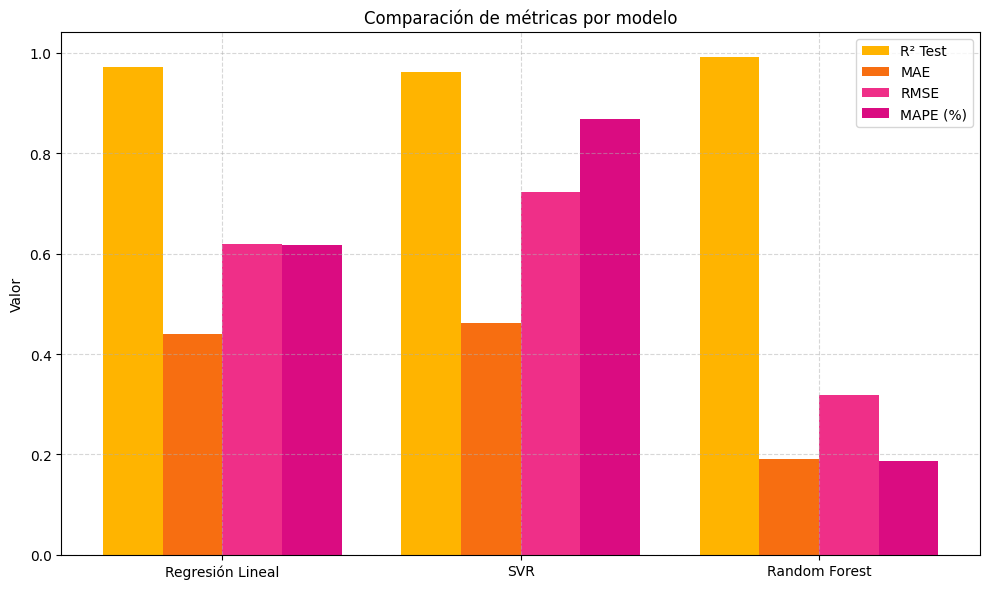

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de los modelos
modelos = ['Regresión Lineal', 'SVR', 'Random Forest']

# Métricas extraídas de tu tabla
r2_test = [0.9716, 0.9615, 0.9925]
mae = [0.4390, 0.4623, 0.1904]
rmse = [0.6202, 0.7228, 0.3189]
mape = [0.6182, 0.8678, 0.1871]

# Posición de las barras
x = np.arange(len(modelos))
width = 0.2

# Crear gráfico
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - 1.5*width, r2_test, width, label='R² Test', color='#FFB400')
ax.bar(x - 0.5*width, mae, width, label='MAE', color='#F76E11')
ax.bar(x + 0.5*width, rmse, width, label='RMSE', color='#EF2F88')
ax.bar(x + 1.5*width, mape, width, label='MAPE (%)', color='#DA0C81')

# Personalización
ax.set_ylabel('Valor')
ax.set_title('Comparación de métricas por modelo')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
